In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os

In [2]:
omnis=[]
for i in glob.glob("Temp_Data/omni*.lst.txt"):
    names=["Year","Day","Hour","Minute","IMF_avg","BX","BY","BZ","Speed","Density","Temperature"]
    df=pd.read_csv(i,names=names,delimiter="\s+")
    omnis.append(df)
omnis=pd.concat(omnis)
omnis['datetime'] = pd.to_datetime(omnis['Year'] * 1000 + omnis['Day'], format='%Y%j') + \
                 pd.to_timedelta(omnis['Hour'], unit='h') + \
                 pd.to_timedelta(omnis['Minute'], unit='m')
omnis=omnis.replace(9.999990e+03,np.nan)
omnis=omnis.replace(9.999990e+04,np.nan)
omnis=omnis.replace(9.999900e+02,np.nan)
omnis=omnis.replace(9.999999e+06,np.nan)
omnis=omnis.drop(columns=["Year","Day","Hour","Minute"]).set_index("datetime")
omnis.index.name = None
omnis=omnis.apply(pd.to_numeric, errors='coerce')
omnis=omnis.resample('2min').mean()
omnis=omnis[(omnis.index >= "2016")&(omnis.index <= "2026-01-01")]

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_4727/2755089880.py:4: SyntaxWarning: invalid escape sequence '\s'
  df=pd.read_csv(i,names=names,delimiter="\s+")


In [3]:
print(omnis.head())

                     IMF_avg     BX     BY      BZ   Speed  Density  \
2016-01-01 00:00:00   15.355  4.630 -0.510 -14.625  454.20    2.755   
2016-01-01 00:02:00   15.330  4.510 -0.435 -14.640  454.80    2.855   
2016-01-01 00:04:00   15.275  4.325 -0.330 -14.640  454.80    2.710   
2016-01-01 00:06:00   15.250  4.540 -0.535 -14.545  456.45    2.945   
2016-01-01 00:08:00   15.230  4.540 -0.430 -14.525  456.25    2.910   

                     Temperature  
2016-01-01 00:00:00      41549.0  
2016-01-01 00:02:00      37767.5  
2016-01-01 00:04:00      42845.0  
2016-01-01 00:06:00      39510.0  
2016-01-01 00:08:00      45585.0  


In [4]:
feid = pd.read_csv("feid-3.csv")
feid["time"] = pd.to_datetime(feid["time"])
feid = feid.rename(columns={"time": "datetime"})
feid = feid.set_index("datetime")
feid.index.name = None

# Separar columnas de texto antes de convertir a numérico
text_cols = ['ons type']   # columnas que deben quedarse como string
num_cols  = [c for c in feid.columns if c not in text_cols]

feid[num_cols] = feid[num_cols].apply(pd.to_numeric, errors='coerce')
# 'ons type' queda como object (string) intacto

feid = feid[(feid.index >= "2016") & (feid.index <= "2026-01-01")]

# Verificar
print(feid.dtypes)
print("\nValores únicos en 'ons type':")
print(feid['ons type'].value_counts(dropna=False))

duration       int64
magnitude    float64
ons type      object
V max        float64
B max        float64
dtype: object

Valores únicos en 'ons type':
ons type
NaN    1342
SSC     112
SI       21
Name: count, dtype: int64


In [5]:
print(feid.head())

                     duration  magnitude ons type  V max  B max
2016-01-01 21:00:00        23       0.67      NaN  490.0    9.8
2016-01-03 03:00:00        34       0.46      NaN  486.0    8.2
2016-01-05 01:00:00        89       0.70      NaN  618.0   16.1
2016-01-11 04:00:00        84       0.96      NaN  606.0   10.5
2016-01-16 05:00:00        51       0.95      NaN  387.0    7.0


In [6]:
dfs=[]

def loadyear(yea):
    datas=[]
    lst=glob.glob("Temp_Data/nmdb_{}_all_stations_set*.csv".format(yea))
    for j in lst:
        df_i=pd.read_csv(j)
        df_i=df_i.drop(columns="Unnamed: 0")
        df_i=df_i.rename(columns={"DATETIME":"datetime"})
        df_i["datetime"]=pd.to_datetime(df_i["datetime"]).dt.tz_localize(None)
        df_i=df_i.set_index("datetime")
        df_i=df_i.replace('   null',np.nan)
        df_i.index.name = None
        df_i=df_i.apply(pd.to_numeric, errors='coerce')
        datas.append(df_i)
    datas=pd.concat(datas,axis=1)
    return datas



for i in np.arange(2016,2026,1):
    lst=loadyear(i)
    dfs.append(lst)
dfs=pd.concat(dfs,axis=0,ignore_index=False)

/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_4727/2232003040.py:7: DtypeWarning: Columns (6,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(j)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_4727/2232003040.py:7: DtypeWarning: Columns (2,3,5,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(j)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_4727/2232003040.py:7: DtypeWarning: Columns (2,3,4,5,7,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(j)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_4727/2232003040.py:7: DtypeWarning: Columns (2,4,5,6,7,8,9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(j)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_4727/2232003040.py:7: DtypeWarning: Columns (7,11,12) have mixed types. Specify dty

In [7]:
dfs=dfs.resample('2min').mean()
dfs=dfs[(dfs.index >= "2016")&(dfs.index <= "2026-01-01")]
dfs

,INVK,JBGO,NAIN,PWNK,THUL,NEU3,SOPB,SOPO,MRNY,DOMB,...,DJON,TSMB,ATHN,MXCO,NANM,PTFM,CALM,ROME,AATB,BKSN
2016-01-01 00:00:00,180.530,262.203,202.744,206.996,116.550,0.881,144.656,294.53,NaN,4.368,...,136.615,NaN,54.767,220.334,450.377,56.388,72.833,150.383,1337.80,118.972
2016-01-01 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,139.115,NaN,53.805,217.500,456.048,58.602,68.608,148.041,1331.50,118.210
2016-01-01 00:04:00,181.378,267.464,201.068,204.328,115.294,0.909,143.722,292.03,NaN,4.334,...,137.889,NaN,58.340,221.666,457.507,56.525,69.867,150.992,1338.35,118.451
2016-01-01 00:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,137.213,NaN,56.878,221.583,460.224,55.122,76.117,152.834,1336.00,119.178
2016-01-01 00:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,134.501,NaN,55.221,222.250,453.315,56.582,73.275,150.934,1336.00,118.479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 23:50:00,168.228,NaN,187.528,189.346,106.404,NaN,119.142,249.78,NaN,4.506,...,NaN,NaN,51.219,209.916,NaN,NaN,68.858,NaN,NaN,113.588
2025-12-31 23:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,52.032,209.034,NaN,NaN,69.883,NaN,NaN,110.972
2025-12-31 23:54:00,167.484,NaN,185.360,187.654,110.150,NaN,118.224,254.02,NaN,4.560,...,NaN,NaN,53.808,207.400,NaN,NaN,68.625,NaN,NaN,112.953
2025-12-31 23:56:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,50.241,207.800,NaN,NaN,70.108,NaN,NaN,113.960


In [8]:
a=pd.DataFrame(dfs.isnull().sum()/len(dfs)*100)
len(a)

42

In [9]:
dfs=dfs[a[a[0]<30][0].index]

In [10]:
a[a[0]<30][0].index

Index(['NEWK', 'KIEL2', 'KERG', 'OULU', 'APTY', 'FSMT', 'JUNG', 'JUNG1',
       'LMKS', 'DRBS', 'ATHN', 'MXCO', 'NANM', 'CALM', 'ROME', 'AATB', 'BKSN'],
      dtype='object')

In [11]:
#print(dfs.head())

In [12]:
#alldata=pd.concat([dfs,omnis,feid],axis=1)
#alldata

In [13]:
#alldata[alldata.index=="2016-01-01 21:00:00"]

In [14]:
# BLOQUE 1: Imputación conservadora (gaps <= 1 hora = 30 pasos de 2 min)
# ============================================================
 
MAX_GAP_STEPS = 30  # 1 hora a resolución 2 min
 
def conservative_interpolate(df, max_gap=MAX_GAP_STEPS):
    """
    Interpolación lineal solo para gaps de NaN <= max_gap pasos consecutivos.
    Todo gap mayor queda como NaN.
    Funciona columna por columna para no mezclar lógica entre variables.
    """
    df_interp = df.copy()
    for col in df.columns:
        s = df[col]
        mask = s.isna()
        if not mask.any():
            continue
        # Tamaño de cada grupo de NaNs consecutivos
        group = mask.ne(mask.shift()).cumsum()
        gap_sizes = mask.groupby(group).transform('sum')
        can_interp = mask & (gap_sizes <= max_gap)
        # Interpolar toda la serie y restaurar gaps grandes
        s_interp = s.interpolate(method='linear', limit_area='inside')
        s_interp[mask & ~can_interp] = np.nan
        df_interp[col] = s_interp
    return df_interp
 
print("Aplicando imputación conservadora a NMDB...")
dfs_clean = conservative_interpolate(dfs)
print(f"  NaN antes:   {dfs.isna().sum().sum():>12,}")
print(f"  NaN después: {dfs_clean.isna().sum().sum():>12,}")
print(f"  Recuperados: {(dfs.isna().sum().sum() - dfs_clean.isna().sum().sum()):>12,}")
 
print("\nAplicando imputación conservadora a OMNI...")
omnis_clean = conservative_interpolate(omnis)
print(f"  NaN antes:   {omnis.isna().sum().sum():>12,}")
print(f"  NaN después: {omnis_clean.isna().sum().sum():>12,}")
print(f"  Recuperados: {(omnis.isna().sum().sum() - omnis_clean.isna().sum().sum()):>12,}")

Aplicando imputación conservadora a NMDB...
  NaN antes:      2,227,502
  NaN después:    2,185,895
  Recuperados:       41,607

Aplicando imputación conservadora a OMNI...
  NaN antes:      1,884,065
  NaN después:      708,699
  Recuperados:    1,175,366


In [15]:
# BLOQUE 2: Preparación del catálogo FEID (sin expansión temporal)
# ============================================================
# El FEID entra como catálogo de referencia para matching evento-a-evento,
# NO como serie temporal continua (64% de cobertura lo hacía inútil como etiqueta).
 
print("\nPreparando catálogo FEID...")
 
feid_clean = feid.copy()
 
# Clasificación de onset
ons_col = 'ons type'
feid_clean['ons_label'] = feid_clean[ons_col].map({
    'SSC': 'ICME-shock',
    'SI':  'weak-impulse'
})
# NaN en ons_label → sin choque identificado (candidatos CIR/SIR/difusos)
feid_clean['has_shock'] = feid_clean[ons_col].isin(['SSC', 'SI'])

# ── Estadísticas por año ──────────────────────────────────────────────────────
print("\n  Eventos FEID por año y tipo de onset:")
yearly_shock = (
    feid_clean
    .groupby([feid_clean.index.year, 'has_shock'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: 'sin_choque', True: 'con_choque'})
)
yearly_shock['total'] = yearly_shock.sum(axis=1)
yearly_shock['pct_sin_choque'] = (yearly_shock['sin_choque'] / yearly_shock['total'] * 100).round(1)
print(yearly_shock.to_string())
 
print("\n  Magnitud media por año (%):")
print(feid_clean.groupby(feid_clean.index.year)['magnitude'].describe()[
    ['count','mean','std','min','max']].round(2).to_string())
 
print("\n  Magnitud media por tipo de onset:")
print(feid_clean.groupby(ons_col)['magnitude'].describe()[
    ['count','mean','std']].round(2).to_string())


Preparando catálogo FEID...

  Eventos FEID por año y tipo de onset:
has_shock  sin_choque  con_choque  total  pct_sin_choque
2016              141          11    152            92.8
2017              115          15    130            88.5
2018              122           9    131            93.1
2019              137           2    139            98.6
2020              127           3    130            97.7
2021              145          13    158            91.8
2022              188          19    207            90.8
2023              174          33    207            84.1
2024              193          28    221            87.3

  Magnitud media por año (%):
      count  mean   std   min    max
2016  152.0  0.84  0.48  0.17   3.07
2017  129.0  0.80  0.76  0.15   5.76
2018  131.0  0.58  0.33  0.19   1.99
2019  139.0  0.51  0.23  0.16   1.30
2020  130.0  0.54  0.27  0.15   1.85
2021  158.0  0.70  0.81  0.20   9.70
2022  207.0  0.85  0.72  0.25   5.89
2023  207.0  0.94  0.90  0.00   6

In [16]:
# BLOQUE 3: Merge NMDB + OMNI (sin FEID en el índice continuo)
# ============================================================
 
print("\nConstruyendo dataset integrado (NMDB + OMNI)...")
 
alldata = pd.concat([dfs_clean, omnis_clean], axis=1)
alldata = alldata.sort_index()
alldata = alldata[(alldata.index >= "2016") & (alldata.index <= "2026-01-01 23:58:00")]
 
nmdb_cols = list(dfs_clean.columns)
omni_cols = list(omnis_clean.columns)
 
print(f"  Shape final:  {alldata.shape}")
print(f"  Rango:        {alldata.index.min()}  →  {alldata.index.max()}")
 
nan_pct = alldata.isna().mean() * 100
print("\n  % NaN — NMDB:")
print(nan_pct[nmdb_cols].round(2).to_string())
print("\n  % NaN — OMNI:")
print(nan_pct[omni_cols].round(2).to_string())


Construyendo dataset integrado (NMDB + OMNI)...
  Shape final:  (2630160, 24)
  Rango:        2016-01-01 00:00:00  →  2025-12-31 23:58:00

  % NaN — NMDB:
NEWK      1.45
KIEL2    12.26
KERG      3.43
OULU      0.00
APTY      0.16
FSMT      0.98
JUNG      0.46
JUNG1     0.40
LMKS      0.09
DRBS      3.16
ATHN      7.51
MXCO      0.88
NANM     26.42
CALM     12.39
ROME      5.29
AATB      3.49
BKSN      4.73

  % NaN — OMNI:
IMF_avg        3.79
BX             3.79
BY             3.79
BZ             3.79
Speed          3.93
Density        3.93
Temperature    3.94


In [17]:
# BLOQUE 4: Guardar
# ============================================================
 
print("\nGuardando...")
 
# Serie temporal integrada 2-min
alldata.to_parquet("alldata_integrated_2min.parquet")
print("  ✓ alldata_integrated_2min.parquet  (NMDB + OMNI, 2-min)")
 
# Versión 1-hora para exploración y figuras
alldata_1h = alldata.resample('1h').mean()
alldata_1h.to_parquet("alldata_integrated_1h.parquet")
print("  ✓ alldata_integrated_1h.parquet   (NMDB + OMNI, 1-h)")
 
# Catálogo FEID limpio con clasificación de onset
feid_clean.to_parquet("feid_clean.parquet")
print("  ✓ feid_clean.parquet              (catálogo eventos, para matching)")
 
# Guardar también lista de columnas para el siguiente notebook
import json
meta = {'nmdb_cols': nmdb_cols, 'omni_cols': omni_cols}
with open("dataset_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("  ✓ dataset_meta.json               (nombres de columnas por bloque)")
 
print("\nListo. Próximo paso: 003_AFTER_detector.ipynb")
print(f"  Dataset: {alldata.shape[0]:,} filas × {alldata.shape[1]} columnas")
print(f"  FEID:    {len(feid_clean):,} eventos de referencia")


Guardando...
  ✓ alldata_integrated_2min.parquet  (NMDB + OMNI, 2-min)
  ✓ alldata_integrated_1h.parquet   (NMDB + OMNI, 1-h)
  ✓ feid_clean.parquet              (catálogo eventos, para matching)
  ✓ dataset_meta.json               (nombres de columnas por bloque)

Listo. Próximo paso: 003_AFTER_detector.ipynb
  Dataset: 2,630,160 filas × 24 columnas
  FEID:    1,475 eventos de referencia


In [18]:
alldata

,NEWK,KIEL2,KERG,OULU,APTY,FSMT,JUNG,JUNG1,LMKS,DRBS,...,ROME,AATB,BKSN,IMF_avg,BX,BY,BZ,Speed,Density,Temperature
2016-01-01 00:00:00,90.320,159.886,210.534,101.559,163.138,197.940,156.200,358.433,450.107,100.792,...,150.383,1337.80,118.972,15.355,4.630,-0.510,-14.625,454.20,2.755,41549.0
2016-01-01 00:02:00,93.055,164.295,214.184,100.245,166.748,198.530,154.273,352.618,447.650,102.192,...,148.041,1331.50,118.210,15.330,4.510,-0.435,-14.640,454.80,2.855,37767.5
2016-01-01 00:04:00,93.885,161.678,213.430,98.682,164.794,200.185,152.399,357.592,453.497,101.433,...,150.992,1338.35,118.451,15.275,4.325,-0.330,-14.640,454.80,2.710,42845.0
2016-01-01 00:06:00,96.435,162.590,209.136,101.608,166.910,201.450,153.116,355.105,447.637,100.925,...,152.834,1336.00,119.178,15.250,4.540,-0.535,-14.545,456.45,2.945,39510.0
2016-01-01 00:08:00,94.215,163.924,211.179,99.189,163.677,200.705,152.341,357.115,449.219,99.950,...,150.934,1336.00,118.479,15.230,4.540,-0.430,-14.525,456.25,2.910,45585.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 23:50:00,83.720,160.039,196.345,92.047,151.847,185.980,143.681,332.755,397.279,96.196,...,NaN,NaN,113.588,9.715,0.800,-9.635,0.625,477.05,3.735,56743.0
2025-12-31 23:52:00,85.920,162.323,200.335,94.826,152.400,184.720,144.865,335.127,395.553,98.066,...,NaN,NaN,110.972,9.795,-1.045,-9.635,1.165,486.15,3.640,68356.5
2025-12-31 23:54:00,84.735,160.648,198.080,97.041,157.621,186.370,143.559,330.541,399.098,93.105,...,NaN,NaN,112.953,9.825,-1.750,-9.555,1.385,501.00,3.385,57600.0
2025-12-31 23:56:00,88.705,162.620,194.537,96.814,154.368,186.980,148.034,335.700,403.861,95.082,...,NaN,NaN,113.960,9.740,-1.140,-9.570,0.970,491.35,3.005,42253.0


<Axes: >

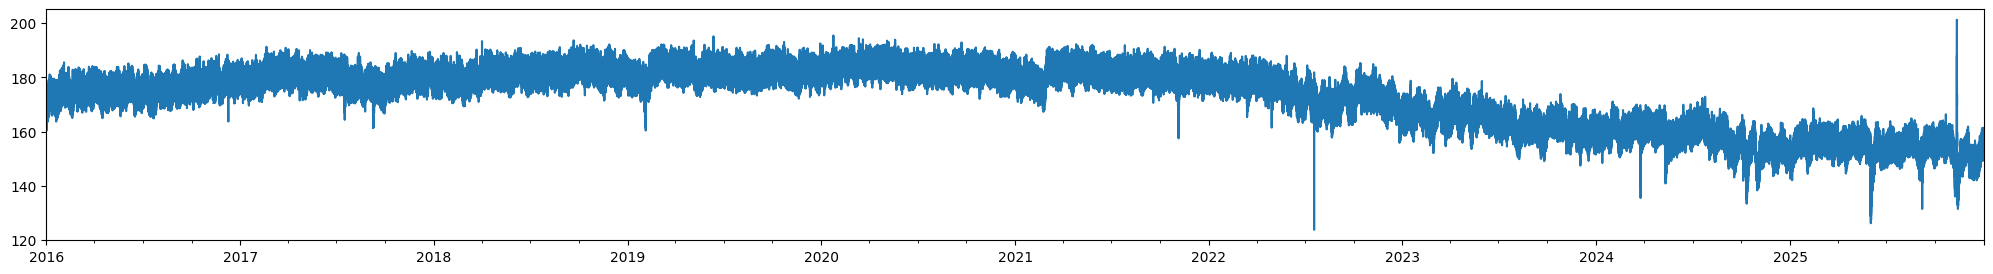

In [19]:
alldata["APTY"].plot(figsize=(25,3))

In [20]:
# Catálogo de eventos FEID limpio (para análisis de eventos individuales)
feid_clean = feid.copy()
ons_col = 'ons type' if 'ons type' in feid_clean.columns else 'ons'
feid_clean['ons_label'] = feid_clean[ons_col].map({
    'SSC': 'ICME-shock',
    'SI':  'weak-impulse',
    'iSW': 'in-situ-SW'
})
feid_clean.to_parquet("feid_clean.parquet")
print("  ✓ feid_clean.parquet")

  ✓ feid_clean.parquet


In [21]:
feid[(feid.index>="2019")&(feid.index<"2020")]

,duration,magnitude,ons type,V max,B max
2019-01-04 12:00:00,83,1.29,NaN,554.0,11.4
2019-01-08 06:00:00,40,0.44,NaN,446.0,6.1
2019-01-10 14:00:00,47,0.55,NaN,509.0,7.3
2019-01-13 01:00:00,19,0.34,NaN,366.0,3.4
2019-01-13 23:00:00,31,0.34,NaN,403.0,10.2
...,...,...,...,...,...
2019-12-14 12:00:00,60,0.66,NaN,413.0,7.9
2019-12-17 23:00:00,85,0.84,NaN,540.0,9.5
2019-12-23 23:00:00,27,0.34,NaN,350.0,5.4
2019-12-25 06:00:00,78,0.65,NaN,408.0,8.3
